# Connect to R

In [16]:
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


# Connect to Google Drive

In [17]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


# Read in Files

In [18]:
%%R

library(dplyr)

# read restricted patient SEQN file
post_2_restricted_patients <- read.csv(
  "/content/drive/MyDrive/masters_thesis/NHANES-2-Cleaner/Post_2-Restricted_Patients.csv"
)

# read steps hour file
steps_hour <- read.csv(
  "/content/drive/MyDrive/masters_thesis/NHANES-2-Cleaner/steps_hour.csv"
)

# preview first 5 rows
cat("Post_2_Restricted_Patients:\n")
print(head(post_2_restricted_patients, 5))

cat("\nsteps_hour:\n")
print(head(steps_hour, 5))

Post_2_Restricted_Patients:
   SEQN
1 62174
2 62177
3 62178
4 62179
5 62191

steps_hour:
   SEQN PAXDAYM HOUR steps_in_hour
1 73557       2    0             0
2 73557       3    0             0
3 73557       4    0             0
4 73557       5    0             0
5 73557       6    0             0


Plotting another patient's weekly hourly steps...

Selected patient: 62177 

Rows for patient:
[1] 168

First few rows:
    SEQN PAXDAYM HOUR steps_in_hour
1  62177       2    0            25
2  62177       2    1             3
3  62177       2    2            62
4  62177       2    3            26
5  62177       2    4             2
6  62177       2    5             3
7  62177       2    6            10
8  62177       2    7             0
9  62177       2    8            12
10 62177       2    9             7


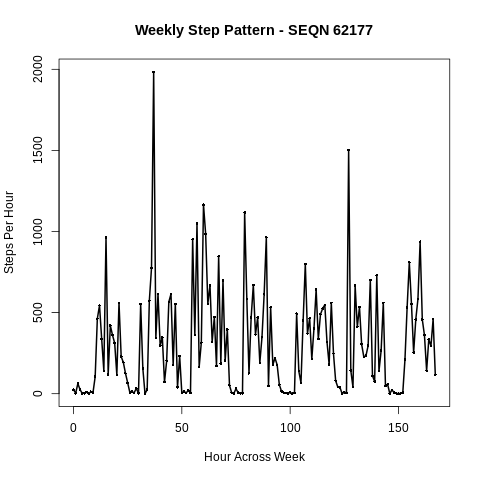

In [19]:
%%R

library(dplyr)

cat("Plotting another patient's weekly hourly steps...\n\n")

# ----------------------------
# 1. Pick another patient
# ----------------------------

patient_id <- post_2_restricted_patients$SEQN[2]

cat("Selected patient:", patient_id, "\n\n")

# ----------------------------
# 2. Filter patient data
# ----------------------------

patient_week <- steps_hour %>%
  filter(SEQN == patient_id) %>%
  arrange(PAXDAYM, HOUR)

cat("Rows for patient:\n")
print(nrow(patient_week))

cat("\nFirst few rows:\n")
print(head(patient_week, 10))

# ----------------------------
# 3. Create continuous hour index
# ----------------------------

patient_week <- patient_week %>%
  mutate(
    continuous_hour = (PAXDAYM - min(PAXDAYM)) * 24 + HOUR
  )

# ----------------------------
# 4. Plot
# ----------------------------

plot(
  patient_week$continuous_hour,
  patient_week$steps_in_hour,
  type = "l",
  lwd = 2,
  xlab = "Hour Across Week",
  ylab = "Steps Per Hour",
  main = paste("Weekly Step Pattern - SEQN", patient_id)
)

points(
  patient_week$continuous_hour,
  patient_week$steps_in_hour,
  pch = 16,
  cex = 0.5
)

# Do FPCA

Starting raw Fourier-smoothed weekly FPCA setup...

Restricted patients: 4625 
Rows in steps_hour: 2432352 

Rows after restricting steps: 768672 
Patients with step data: 4625 
week_hour range:
[1]   0 167

Patient grid dimensions:
[1] 777000      2
Complete weekly grid rows: 777000 
Missing hourly step values: 8328 

Missing values after imputation: 0 

Step matrix dimensions:
[1] 4625  168

Step matrix missing values:
[1] 0

Step matrix first patient first 10 hours:
hour_0 hour_1 hour_2 hour_3 hour_4 hour_5 hour_6 hour_7 hour_8 hour_9 
    57     25     24     26     50     28     18     12      5    196 

Applying Fourier smoothing...
Length of t:
[1] 168
First few t values:
[1] 0.000000000 0.005988024 0.011976048 0.017964072 0.023952096 0.029940120

Initial Fourier basis dimensions:
[1] 168   1
Adding Fourier term: 1 
  sin length: 168 
  cos length: 168 
  Fourier basis dimensions now:
[1] 168   3
Adding Fourier term: 2 
  sin length: 168 
  cos length: 168 
  Fourier basis dimen

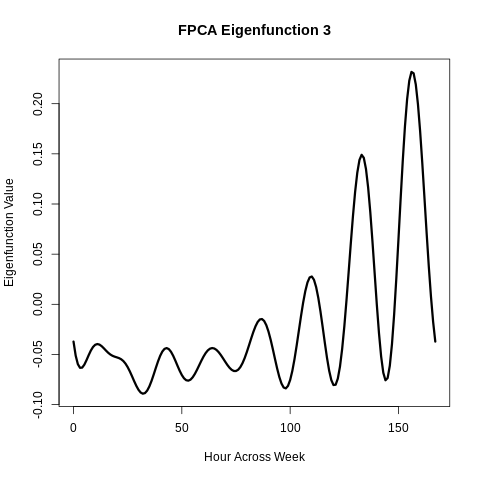

In [20]:
%%R

library(dplyr)

cat("Starting raw Fourier-smoothed weekly FPCA setup...\n\n")

# ----------------------------
# 1. Read files
# ----------------------------

post_2_restricted_patients <- read.csv(
  "/content/drive/MyDrive/masters_thesis/NHANES-2-Cleaner/Post_2-Restricted_Patients.csv"
) %>%
  distinct(SEQN)

steps_hour <- read.csv(
  "/content/drive/MyDrive/masters_thesis/NHANES-2-Cleaner/steps_hour.csv"
)

cat("Restricted patients:", nrow(post_2_restricted_patients), "\n")
cat("Rows in steps_hour:", nrow(steps_hour), "\n\n")

# ----------------------------
# 2. Restrict steps to patients
# ----------------------------

steps_restricted <- steps_hour %>%
  inner_join(post_2_restricted_patients, by = "SEQN") %>%
  group_by(SEQN) %>%
  mutate(
    week_hour = (PAXDAYM - min(PAXDAYM, na.rm = TRUE)) * 24 + HOUR
  ) %>%
  ungroup()

cat("Rows after restricting steps:", nrow(steps_restricted), "\n")
cat("Patients with step data:", n_distinct(steps_restricted$SEQN), "\n")
cat("week_hour range:\n")
print(range(steps_restricted$week_hour, na.rm = TRUE))
cat("\n")

# ----------------------------
# 3. Build complete 168-hour patient grid
# ----------------------------

patient_grid <- expand.grid(
  SEQN = unique(steps_restricted$SEQN),
  week_hour = 0:167
)

cat("Patient grid dimensions:\n")
print(dim(patient_grid))

steps_weekly <- patient_grid %>%
  left_join(
    steps_restricted %>%
      filter(week_hour >= 0, week_hour <= 167) %>%
      group_by(SEQN, week_hour) %>%
      summarise(
        steps_in_hour = mean(steps_in_hour, na.rm = TRUE),
        .groups = "drop"
      ),
    by = c("SEQN", "week_hour")
  ) %>%
  arrange(SEQN, week_hour)

cat("Complete weekly grid rows:", nrow(steps_weekly), "\n")
cat("Missing hourly step values:", sum(is.na(steps_weekly$steps_in_hour)), "\n\n")

# ----------------------------
# 4. Impute missing hours with patient mean
# ----------------------------

steps_weekly <- steps_weekly %>%
  group_by(SEQN) %>%
  mutate(
    patient_mean_steps = mean(steps_in_hour, na.rm = TRUE),
    steps_imputed = if_else(
      is.na(steps_in_hour),
      patient_mean_steps,
      steps_in_hour
    )
  ) %>%
  ungroup() %>%
  mutate(
    steps_imputed = if_else(
      is.na(steps_imputed),
      0,
      steps_imputed
    )
  )

cat("Missing values after imputation:", sum(is.na(steps_weekly$steps_imputed)), "\n\n")

# ----------------------------
# 5. Convert to patient x 168 matrix
# ----------------------------

patient_ids <- sort(unique(steps_weekly$SEQN))

step_matrix <- steps_weekly %>%
  arrange(SEQN, week_hour) %>%
  pull(steps_imputed) %>%
  matrix(
    nrow = length(patient_ids),
    ncol = 168,
    byrow = TRUE
  )

rownames(step_matrix) <- patient_ids
colnames(step_matrix) <- paste0("hour_", 0:167)

cat("Step matrix dimensions:\n")
print(dim(step_matrix))

cat("\nStep matrix missing values:\n")
print(sum(is.na(step_matrix)))

cat("\nStep matrix first patient first 10 hours:\n")
print(step_matrix[1, 1:10])

# ----------------------------
# 6. Fourier smoothing using base R
# ----------------------------

cat("\nApplying Fourier smoothing...\n")

fourier_terms <- 10
t <- seq(0, 1, length.out = 168)

cat("Length of t:\n")
print(length(t))

cat("First few t values:\n")
print(head(t))

fourier_basis <- data.frame(
  intercept = rep(1, length(t))
)

cat("\nInitial Fourier basis dimensions:\n")
print(dim(fourier_basis))

for (k in 1:fourier_terms) {

  cat("Adding Fourier term:", k, "\n")

  sin_vec <- sin(2 * pi * k * t)
  cos_vec <- cos(2 * pi * k * t)

  cat("  sin length:", length(sin_vec), "\n")
  cat("  cos length:", length(cos_vec), "\n")

  fourier_basis[[paste0("sin_", k)]] <- sin_vec
  fourier_basis[[paste0("cos_", k)]] <- cos_vec

  cat("  Fourier basis dimensions now:\n")
  print(dim(fourier_basis))
}

fourier_basis_matrix <- as.matrix(fourier_basis)

cat("\nFinal Fourier basis matrix dimensions:\n")
print(dim(fourier_basis_matrix))

cat("\nFirst few rows of Fourier basis:\n")
print(head(fourier_basis_matrix[, 1:5]))

cat("\nChecking dimensions before smoothing:\n")
cat("Rows in step_matrix:", nrow(step_matrix), "\n")
cat("Columns in step_matrix:", ncol(step_matrix), "\n")
cat("Rows in Fourier basis:", nrow(fourier_basis_matrix), "\n")
cat("Columns in Fourier basis:", ncol(fourier_basis_matrix), "\n\n")

if (ncol(step_matrix) != nrow(fourier_basis_matrix)) {
  stop("Dimension mismatch: step_matrix columns must equal Fourier basis rows.")
}

smooth_one_patient <- function(y) {

  if (length(y) != nrow(fourier_basis_matrix)) {
    stop("Patient vector length does not match Fourier basis rows.")
  }

  fit <- lm(y ~ fourier_basis_matrix - 1)
  as.numeric(fitted(fit))
}

cat("Testing smoothing on first patient...\n")
test_smooth <- smooth_one_patient(step_matrix[1, ])

cat("Length of smoothed first patient:\n")
print(length(test_smooth))

cat("First 10 smoothed values:\n")
print(round(test_smooth[1:10], 2))

cat("\nSmoothing all patients...\n")

smoothed_matrix <- t(apply(step_matrix, 1, smooth_one_patient))

rownames(smoothed_matrix) <- patient_ids
colnames(smoothed_matrix) <- paste0("hour_", 0:167)

cat("Smoothed matrix dimensions:\n")
print(dim(smoothed_matrix))

cat("\nSmoothed matrix missing values:\n")
print(sum(is.na(smoothed_matrix)))

# ----------------------------
# 7. Run FPCA using PCA on smoothed functions
# ----------------------------

cat("\nRunning FPCA using PCA on smoothed weekly curves...\n")

fpca_fit <- prcomp(
  smoothed_matrix,
  center = TRUE,
  scale. = FALSE
)

cat("FPCA complete.\n\n")

variance_explained <- fpca_fit$sdev^2 / sum(fpca_fit$sdev^2)

cat("Variance explained by first 10 PCs:\n")
print(round(variance_explained[1:10], 4))


hours <- 0:167

plot(
  hours,
  fpca_fit$rotation[, 1],
  type = "l",
  lwd = 3,
  xlab = "Hour Across Week",
  ylab = "Eigenfunction Value",
  main = "FPCA Eigenfunction 1"
)

plot(
  hours,
  fpca_fit$rotation[, 2],
  type = "l",
  lwd = 3,
  xlab = "Hour Across Week",
  ylab = "Eigenfunction Value",
  main = "FPCA Eigenfunction 2"
)

plot(
  hours,
  fpca_fit$rotation[, 3],
  type = "l",
  lwd = 3,
  xlab = "Hour Across Week",
  ylab = "Eigenfunction Value",
  main = "FPCA Eigenfunction 3"
)

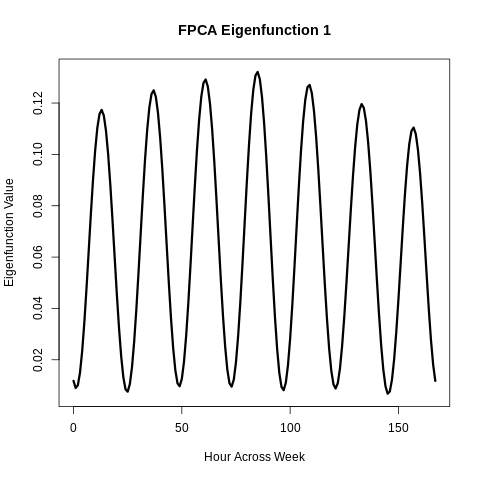

In [21]:
%%R

plot(
  hours,
  fpca_fit$rotation[, 1],
  type = "l",
  lwd = 3,
  xlab = "Hour Across Week",
  ylab = "Eigenfunction Value",
  main = "FPCA Eigenfunction 1"
)

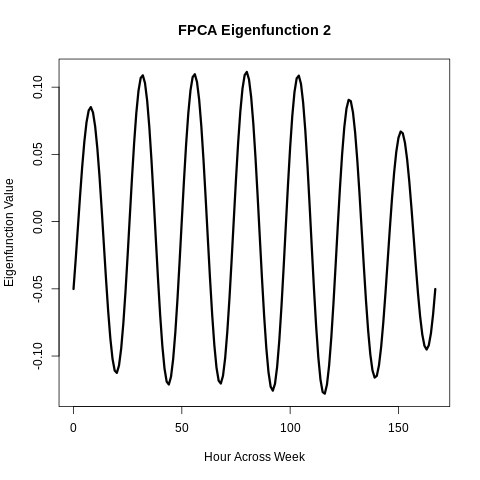

In [22]:
%%R

plot(
  hours,
  fpca_fit$rotation[, 2],
  type = "l",
  lwd = 3,
  xlab = "Hour Across Week",
  ylab = "Eigenfunction Value",
  main = "FPCA Eigenfunction 2"
)

Creating scree plot...

First 10 variance explained values:
 [1] 0.5138 0.1130 0.0518 0.0474 0.0399 0.0302 0.0263 0.0233 0.0215 0.0198

Cumulative variance explained:
 [1] 0.5138 0.6268 0.6786 0.7259 0.7659 0.7961 0.8224 0.8457 0.8673 0.8871


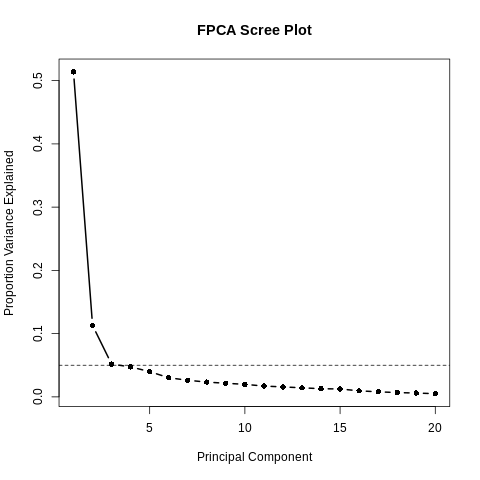

In [23]:
%%R

cat("Creating scree plot...\n\n")

# ----------------------------
# Calculate variance explained
# ----------------------------

variance_explained <- fpca_fit$sdev^2 / sum(fpca_fit$sdev^2)

cat("First 10 variance explained values:\n")
print(round(variance_explained[1:10], 4))

# ----------------------------
# Scree plot
# ----------------------------

plot(
  variance_explained[1:20],
  type = "b",
  pch = 16,
  lwd = 2,
  xlab = "Principal Component",
  ylab = "Proportion Variance Explained",
  main = "FPCA Scree Plot"
)

# optional cumulative variance
cumulative_variance <- cumsum(variance_explained)

cat("\nCumulative variance explained:\n")
print(round(cumulative_variance[1:10], 4))

# optional horizontal reference line
abline(h = 0.05, lty = 2)

# Save FPCA Scores

In [24]:
%%R

# ----------------------------
# 8. Save patient FPCA scores
# ----------------------------

fpca_scores <- data.frame(
  SEQN = as.numeric(rownames(fpca_fit$x)),
  FPCA_score_1 = fpca_fit$x[, 1],
  FPCA_score_2 = fpca_fit$x[, 2],
  FPCA_score_3 = fpca_fit$x[, 3]
)

cat("\nFirst few FPCA scores:\n")
print(head(fpca_scores))

write.csv(
  fpca_scores,
  "/content/drive/MyDrive/masters_thesis/NHANES-2-Cleaner/Post_3_FPCA_Scores.csv",
  row.names = FALSE
)

cat("\nSaved FPCA scores to:\n")
cat("/content/drive/MyDrive/masters_thesis/NHANES-2-Cleaner/Post_3_FPCA_Scores.csv\n")



First few FPCA scores:
       SEQN FPCA_score_1 FPCA_score_2 FPCA_score_3
62174 62174   -3706.8684     20.76612    127.39131
62177 62177    -293.8723   -640.75925   -167.25043
62178 62178   -3528.3944    230.58990    125.83436
62179 62179   -2140.3545    121.54812   -625.87020
62191 62191   -4165.1917    241.56093      2.38822
62199 62199    2576.5650    590.04805    186.51809

Saved FPCA scores to:
/content/drive/MyDrive/masters_thesis/NHANES-2-Cleaner/Post_3_FPCA_Scores.csv


# Save Curves for Home Assistant

In [25]:
%%R

# =========================================================
# Save ONLY the first eigenfunction
# =========================================================

nhanes_mean_curve <- data.frame(
  week_hour = 0:167,
  mean_steps = as.numeric(fpca_fit$center)
)

nhanes_first_eigenfunction <- data.frame(
  week_hour = 0:167,
  eigenfunction_1 = fpca_fit$rotation[, 1]
)

write.csv(
  nhanes_mean_curve,
  "/content/drive/MyDrive/masters_thesis/NHANES-2-Cleaner/nhanes_mean_curve.csv",
  row.names = FALSE
)

write.csv(
  nhanes_first_eigenfunction,
  "/content/drive/MyDrive/masters_thesis/NHANES-2-Cleaner/nhanes_first_eigenfunction.csv",
  row.names = FALSE
)

cat("Saved mean curve and first eigenfunction.\n")

Saved mean curve and first eigenfunction.


# Histogram of FPCA 1 scores


Creating histogram of FPCA Score 1...
Length of FPCA score vector:
[1] 4625

Summary of FPCA Score 1:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-4719.8 -1973.1  -208.5     0.0  1621.4 14173.0 

Mean of FPCA Score 1:
[1] -4.766027e-14

SD of FPCA Score 1:
[1] 2671.874

Min and Max:
[1] -4719.818 14172.976

Finished histogram.


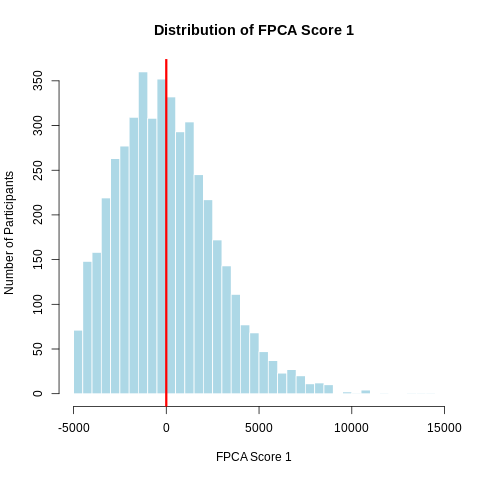

In [26]:
%%R

# ----------------------------
# 8. Histogram of FPCA Score 1
# ----------------------------

cat("\nCreating histogram of FPCA Score 1...\n")

fpca_score_1 <- fpca_fit$x[, 1]

cat("Length of FPCA score vector:\n")
print(length(fpca_score_1))

cat("\nSummary of FPCA Score 1:\n")
print(summary(fpca_score_1))

cat("\nMean of FPCA Score 1:\n")
print(mean(fpca_score_1))

cat("\nSD of FPCA Score 1:\n")
print(sd(fpca_score_1))

cat("\nMin and Max:\n")
print(range(fpca_score_1))

hist(
  fpca_score_1,
  breaks = 50,
  main = "Distribution of FPCA Score 1",
  xlab = "FPCA Score 1",
  ylab = "Number of Participants",
  col = "lightblue",
  border = "white"
)

abline(
  v = mean(fpca_score_1),
  col = "red",
  lwd = 3
)

cat("\nFinished histogram.\n")

In [27]:
%%R

install.packages("rstpm2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘bdsmatrix’, ‘bbmle’, ‘fastGHQuad’, ‘mvtnorm’, ‘numDeriv’, ‘lsoda’, ‘RcppArmadillo’

trying URL 'https://cran.rstudio.com/src/contrib/bdsmatrix_1.3-7.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/bbmle_1.0.25.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/fastGHQuad_1.0.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/mvtnorm_1.3-7.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/numDeriv_2016.8-1.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/lsoda_1.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RcppArmadillo_15.2.6-1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/rstpm2_1.7.1.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmpyp87rh/downloaded_packages’


In [ ]:
%%R

# install.packages("rstpm2")

library(rstpm2)
library(dplyr)

cat("Fitting spline-based survival model...\n\n")

aft_complete <- aft_complete %>%
  mutate(
    FPCA_score_1_z = as.numeric(scale(FPCA_score_1))
  )

# -----------------------------------
# Fit spline survival model
# -----------------------------------

spline_fit <- stpm2(
  Surv(followup_months, death) ~
    FPCA_score_1_z +
    age +
    bmi +
    sex +
    race_ethnicity +
    education +
    marital_status +
    smoking_status +
    alcohol_use +
    hypertension +
    diabetes +
    heart_attack +
    stroke +
    cancer +
    self_rated_health,

  data = aft_complete,

  df = 4
)

cat("Spline model fit complete.\n\n")

print(summary(spline_fit))